# Data Challenge 11 — Evaluating MLR & Fixing Multicollinearity (HVFHV Trips)


**Format:** Instructor Guidance → You Do (Students) → We Share (Reflection)

**Goal:** Build an MLR, evaluate it with a **train–test split**, diagnose multicollinearity with **corr** and **VIF** on the **training set**, fix issues (drop/choose features), and report **test MAE/RMSE** + **coefficient interpretations**.

**Data:** July 1, 2023 - July 15, 2023 For Hire Vehicle Data in NYC

[July For Hire Vehicles Data](https://data.cityofnewyork.us/Transportation/2023-High-Volume-FHV-Trip-Data/u253-aew4/about_data)


## Instructor Guidance

**Hint: Use the Lecture Deck, Canvas Reading, and Docs to help you with the code**

Use this guide live; students implement below.

**Docs (quick links):**
- Train/Test Split — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- OLS — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html
- OLS Results (rsquared_adj, pvalues, resid, etc.): https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html
- VIF — statsmodels: https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html
- Corr — pandas: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html

### Pseudocode Plan (Evaluation + Multicollinearity)
1) **Load CSV** → preview shape/columns; (optional) filter to **July**.
2) **Pick Y** (`base_passenger_fare`) and **candidate X’s** (e.g., `trip_miles`, `trip_time_minutes`, `tolls`, `tips` if present).
3) **Light prep** → derive `trip_time_minutes` from `trip_time` (seconds) if present; coerce only used cols to numeric; drop NA rows.
4) **Split** → `X_train, X_test, y_train, y_test` (80/20, fixed `random_state`).
5) **Diagnose on TRAIN**:
   - **Correlation matrix** (|r| > 0.7 = red flag).
   - **VIF** for each predictor (1–5 ok; >5–10+ = concerning).
6) **Fix** → drop/choose among highly correlated predictors (business logic).
7) **Fit on TRAIN only** → OLS with intercept.
8) **Predict on TEST** → compute **MAE/RMSE** (units of Y).
9) **Interpret** → unit-based coefficient sentences **holding others constant**; note any changes after fixing collinearity.
10) **Report** → table of (features kept, Adj R², MAE, RMSE) + 1-line stakeholder takeaway.


## You Do — Student Section
Work in pairs. Comment your choices briefly. Keep code simple—only coerce the columns you use.

### Step 0 — Setup & Imports

In [ ]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import dataprep
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error



pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### Step 1 — Load CSV & Preview
- Point to your For Hire Vehicle Data 
- Print **shape** and **columns**.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [2]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures/Mod6/data/FHV_072023 copy.csv')
df.head()

/var/folders/bs/gtwb0lj97nb4v95968dmfzww0000gp/T/ipykernel_71525/974174825.py:1: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures/Mod6/data/FHV_072023 copy.csv')


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,HV0005,B03406,NaN,07/01/2023 05:34:30 PM,NaN,07/01/2023 05:37:48 PM,07/01/2023 05:44:45 PM,158,68,1.2660,...,1.3500,2.7500,0.0000,2.0000,5.5700,N,N,N,N,False
1,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:36:53 PM,07/01/2023 05:37:15 PM,07/01/2023 05:55:15 PM,162,234,2.3500,...,1.5200,2.7500,0.0000,3.2800,13.3800,N,N,NaN,N,False
2,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:35:17 PM,07/01/2023 05:35:52 PM,07/01/2023 05:44:27 PM,161,163,0.8100,...,0.4900,2.7500,0.0000,0.0000,5.9500,N,N,NaN,N,False
3,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:37:39 PM,07/01/2023 05:39:35 PM,07/01/2023 06:23:02 PM,122,229,15.4700,...,5.1700,2.7500,0.0000,0.0000,54.4600,N,N,NaN,N,True
4,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:36:06 PM,07/01/2023 05:36:39 PM,07/01/2023 05:45:06 PM,67,14,1.5200,...,0.8500,0.0000,0.0000,3.0000,7.0100,N,N,NaN,N,False


## Data preparation and EDA

In [3]:
# Converting datetime columns to datetime format
datetime_cols = ['request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime']
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

# Convert features to numeric
df['driver_pay'] = pd.to_numeric(df['driver_pay'], errors='coerce')
df['trip_time'] = pd.to_numeric(df['trip_time'], errors='coerce')
df['base_passenger_fare'] = pd.to_numeric(df['base_passenger_fare'], errors='coerce')
df['congestion_surcharge'] = pd.to_numeric(df['congestion_surcharge'], errors='coerce')

# Dropping missing base_passenger_fare
df = df.dropna(subset=['base_passenger_fare'])

# original trip time has lots of missingness , over 40%, I will compute it manually in minutes
# Computung trip_time_cleaned (seconds between pickup and dropoff)
df['trip_time_clean'] = (df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds() / 60


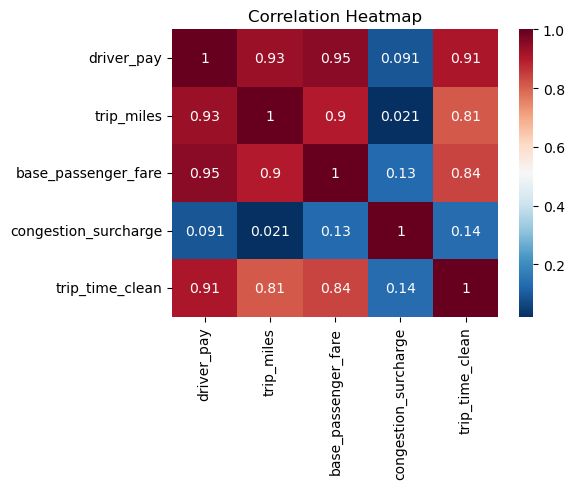

In [11]:
# Correlation heatmap
corr = df[['driver_pay','trip_miles','base_passenger_fare','congestion_surcharge','trip_time_clean']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='RdBu_r')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Step 2 —  Choose Target **Y** and Candidate Predictors

- Suggested **Y**: `base_passenger_fare` (USD).
- Start with **distance** and **time**; optionally add **flags** if present.
- Derive `trip_time_minutes` from `trip_time` (seconds) if available.

In [13]:
y = df['base_passenger_fare']
x1= df['trip_miles']
x2= df['trip_time_clean']
x3= df['congestion_surcharge']

### Step 3 — Train–Test Split

- Use a fixed `random_state` for reproducibility.
- **All diagnostics below must be done on TRAIN only.**

In [ ]:
Xs = df[['trip_miles','trip_time_clean','congestion_surcharge']]
X_train, X_test, y_train, y_test = train_test_split(
    Xs, y, 
    test_size=0.2,
    random_state= 42,
    shuffle= True       
)

### Step 4 — Diagnose Multicollinearity on **TRAIN** — Correlation Matrix
- Flag any |r| > 0.70 as a potential problem.


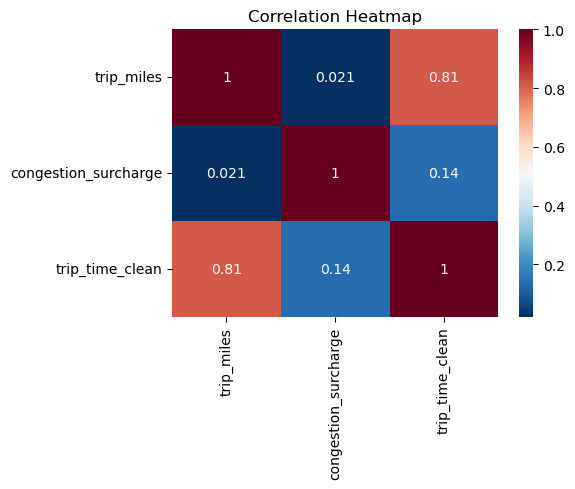

In [ ]:
# Correlation heatmap for X_train
corr_X = X_train[['trip_miles','congestion_surcharge','trip_time_clean']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_X, annot=True, cmap='RdBu_r')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Step 5 — Diagnose Multicollinearity on **TRAIN** — VIF
- 1–5 normal; >5–10+ concerning.

In [22]:
X_train = sm.add_constant(X_train[['trip_miles','trip_time_clean','congestion_surcharge']])
VIF_data = pd.DataFrame()
VIF_data['feature'] = X_train.columns
VIF_data['vif'] = [variance_inflation_factor(X_train.values, i)
                   for i in range(X_train.shape[1])]

print(VIF_data)

                feature    vif
0                 const 3.5357
1            trip_miles 2.9946
2       trip_time_clean 3.0491
3  congestion_surcharge 1.0433


### Step 6 — Fix High VIF (if needed)

- If two predictors are highly correlated, **drop/choose** using business logic (e.g., keep the more actionable one).
- Recompute VIF to confirm improvement.

In [ ]:
# bases on the VIFs, which are all under 5, we do not have high multicolinearity

### Step 7 —  Fit on TRAIN Only, Predict on TEST, Evaluate MAE/RMSE

- Add intercept (`sm.add_constant`).
- Report **MAE/RMSE** in **units of Y**.
- Also capture **Adjusted R²** from the TRAIN fit summary to comment on fit (don’t use it alone for selection).


In [ ]:
# Fitting model on training data 
model = sm.OLS(y_train, X_train).fit()

X_test = sm.add_constant(X_test[['trip_miles','trip_time_clean','congestion_surcharge']])
y_predict = model.predict(X_test)

# Compute MAE and RMSE on test set
mae = mean_absolute_error(y_test, y_predict)
rmse = np.sqrt(mean_squared_error(y_test, y_predict))

print(model.summary())
print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"Adjusted R² (Train): {model.rsquared_adj:.2f}")

                             OLS Regression Results                            
Dep. Variable:     base_passenger_fare   R-squared:                       0.850
Model:                             OLS   Adj. R-squared:                  0.850
Method:                  Least Squares   F-statistic:                 1.255e+07
Date:                 Thu, 06 Nov 2025   Prob (F-statistic):               0.00
Time:                         15:23:57   Log-Likelihood:            -2.3238e+07
No. Observations:              6659660   AIC:                         4.648e+07
Df Residuals:                  6659656   BIC:                         4.648e+07
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

### Step 8 —  Interpret Coefficients (Plain Language)
Write **unit-based** sentences “**holding others constant**.” Example templates (edit with your β values/units):

- **trip_miles:** “Holding other variables constant, each additional **mile** is associated with **+$2.25** in **base fare**.”
- **trip_time_minutes:** “Holding others constant, each additional **minute** is associated with **+$0.44** in **base fare**.”
- ** congestion_surcharge:**  Base Passenger fare increases by $1.77 for every additional charge for congestion ” holding others constant.

*Also note **p-values** and whether they support including each predictor.*
**p-values** are all ~ 0, that's an evidence that the relation between the features and the base fare is statistically significant

## We Share — Reflection & Wrap‑Up

Write **2 short paragraphs** and be specific:

1) **What changes did you make to handle multicollinearity and why?**  
Reference **corr**/**VIF** on TRAIN and any features you dropped or kept (with business rationale). Include **Adjusted R² (TRAIN)** and **TEST MAE/RMSE**.\
While I haven't dealt with multicollinearity because my diagnosis using VIF show that the features do not present a high multicollinearity relation, my plan to handle it if that was the case was either by dropping one of the feature which is not the most relevant in terms of linearity with my response variable "based on domain knowledge", or merge their effect into one feature, by for example scaling them then computing their average as a new interactive feature.

2) **Stakeholder summary (units, one sentence):**  
“On unseen July trips, our typical error is about **$4.15** per fare; each extra mile adds about **$2.25**, holding other factors constant, The baseline fare for any trip is about $2.50.

